# Employee Attrition Analysis

*Identifying the factors that drive employee turnover.*

I'm working with the IBM HR Analytics **Employee Attrition & Performance** dataset
(1,470 employees, 35 columns, from Kaggle). It's a fictional dataset built by IBM data
scientists, so these aren't real people, but it has the realistic shape of an HR table and
it's a good one to practice on.

**The business problem.** A company is losing too many employees and HR wants to understand it:
who leaves most often, why people leave, which groups are most at risk, and what they could
actually do about it.

**The main question I want to answer:**

> *Which factors are most strongly associated with employee attrition, and what can HR do to improve retention?*

Before touching the data I wrote down the questions I wanted to answer and what I *expected* to
find for each one. 

| # | Question | What I expected before looking |
|---|----------|--------------------------------|
| 1 | Does working overtime affect attrition? | Overtime should push attrition up |
| 2 | Is salary (MonthlyIncome) linked to leaving? | Lower pay, more leaving |
| 3 | Which departments / roles lose the most people? | Sales and front-line roles |
| 4 | Do newer employees (YearsAtCompany) leave more? | The first year is the riskiest |
| 5 | How do JobSatisfaction and WorkLifeBalance matter? | Low scores, higher attrition |
| 6 | Does age matter? | Younger people leave more |
| 7 | Any difference by marital status / business travel? | Singles and frequent travellers leave more |
| 8 | Do stock options and job level protect retention? | Yes, both should help keep people |
| 9 | Is there a real difference between men and women? (A/B test) | Honestly not sure - want to test it properly |
| 10 | Do risk factors stack on top of each other? | Probably, but I want to see how much |


## 1. Libraries and plotting helpers

In [1]:
import sqlite3                         # to run real SQL queries on the data (section 5)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

# One colour scheme the whole way through: red = left, blue = stayed.
PAL = {"Yes": "#d1495b", "No": "#3a86a8"}
AVG_LINE = "#1d3557"      # dark navy, used for the "company average" reference line

print("pandas", pd.__version__)

pandas 3.0.0


Two small chart helpers I reuse everywhere, so every chart has labels on **all** of its bars and a
**clearly visible** company-average line:

In [3]:
def label_bars(ax, fmt="%.1f%%", fontsize=11):
    # A seaborn barplot with `hue` makes one "container" per hue level, so I loop
    # over all of them - otherwise only the first group of bars would get labels.
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=fontsize)


def add_avg_line(ax, value, orient="h"):
    # Thick dark-navy dashed line + a small boxed label, so the company baseline
    # stands out against the coloured bars.
    box = dict(boxstyle="round,pad=0.25", fc="white", ec=AVG_LINE, alpha=0.9)
    if orient == "h":                              # horizontal line for vertical bars
        ax.axhline(value, ls="--", lw=2.2, color=AVG_LINE, zorder=5)
        ax.text(0.995, value, f" company avg {value:.1f}% ", color=AVG_LINE, bbox=box,
                transform=ax.get_yaxis_transform(), ha="right", va="bottom", fontsize=10, zorder=6)
    else:                                          # vertical line for horizontal bars
        ax.axvline(value, ls="--", lw=2.2, color=AVG_LINE, zorder=5)
        ax.text(value, 0.99, f" company avg {value:.1f}% ", color=AVG_LINE, bbox=box,
                transform=ax.get_xaxis_transform(), ha="left", va="top", rotation=90,
                fontsize=10, zorder=6)

## 2. Load the data and look at it

First thing to do: load data, check the shape, peek at a few rows and the column types.


In [4]:
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

So it's 1,470 rows and 35 columns, about 1 MB in memory. Most columns are integers, 9 are
text. Every column says `non-null`, so it looks like there are no missing
values, but I'll confirm that properly in the next step. The column I care about is **Attrition**
(Yes/No) - whether the person left.

## 3. Data quality checks



In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows :", df.duplicated().sum())
print("Duplicate EmployeeNumber:", df["EmployeeNumber"].duplicated().sum())

# A column with only one unique value is constant -> it carries no information.
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", {c: df[c].unique().tolist() for c in constant_cols})

Missing values: 0
Duplicate rows : 0
Duplicate EmployeeNumber: 0
Constant columns: {'EmployeeCount': [1], 'Over18': ['Y'], 'StandardHours': [80]}


In [7]:
# Correctness check: nobody can have worked here longer than their entire career,
# so YearsAtCompany should never be greater than TotalWorkingYears.
illogical = df[df["YearsAtCompany"] > df["TotalWorkingYears"]]
print("Rows where YearsAtCompany > TotalWorkingYears:", len(illogical))

# checking PerformanceRating
print("PerformanceRating values:", sorted(df["PerformanceRating"].unique()))

Rows where YearsAtCompany > TotalWorkingYears: 0
PerformanceRating values: [np.int64(3), np.int64(4)]


The data is genuinely clean: **no missing values, no duplicate rows**, EmployeeNumber is unique,
and `YearsAtCompany` never exceeds `TotalWorkingYears`, so no broken tenure values.

Two things I'll act on:

- Three columns are constant (`EmployeeCount` is always 1, `Over18` always 'Y', `StandardHours`
  always 80). They can't explain anything, so I'll drop them.
- `PerformanceRating` only ever takes the values **3 and 4**. Everyone is rated "good" or "excellent",
  nobody is rated 1 or 2. With basically no variation it's useless for explaining attrition, so I
  won't lean on it. In a real project I'd ask HR why the bottom of the scale
  is never used.

## 4. A first pass with SQL

In a real job the data usually lives in a database/warehouse, and the first exploration happens in
SQL before anything touches Python. To show that here I load the raw table into an in-memory
**SQLite** database and run a few queries against it. The same queries work in **BigQuery** with tiny changes.

In [8]:
# Create an in-memory SQLite database and load the raw dataframe into a table.
conn = sqlite3.connect(":memory:")
df.to_sql("employees", conn, index=False, if_exists="replace")

# Tiny helper so each query below reads cleanly and comes back as a DataFrame.
def run_sql(query):
    return pd.read_sql_query(query, conn)

print("Loaded", run_sql("SELECT COUNT(*) AS n FROM employees")["n"][0], "rows into SQLite.")

Loaded 1470 rows into SQLite.


**Query 1 - overall headcount and attrition rate.**

In [9]:
run_sql('''
    SELECT
        COUNT(*)                                            AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)  AS left_company,
        -- AVG of a 1/0 flag is the share of leavers; *100 and round to 2 dp -> %
        ROUND(100.0 * AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END), 2) AS attrition_rate_pct
    FROM employees;
''')

,total_employees,left_company,attrition_rate_pct
0,1470,237,16.12


**Query 2 - attrition rate by department.**

In [10]:
run_sql('''
    SELECT
        Department,
        COUNT(*)                                            AS headcount,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)  AS n_left,
        ROUND(100.0 * AVG(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END), 2) AS attrition_rate_pct
    FROM employees
    GROUP BY Department
    ORDER BY attrition_rate_pct DESC;
''')

,Department,headcount,n_left,attrition_rate_pct
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


**Query 3 - a quick profile of leavers vs stayers (average income and age).**

In [11]:
run_sql('''
    SELECT
        Attrition,
        COUNT(*)                       AS headcount,
        ROUND(AVG(MonthlyIncome), 0)   AS avg_monthly_income,
        ROUND(AVG(Age), 1)             AS avg_age
    FROM employees
    GROUP BY Attrition;
''')

,Attrition,headcount,avg_monthly_income,avg_age
0,No,1233,6833.0,37.6
1,Yes,237,4787.0,33.6


**First conclusions, straight from SQL.** The overall attrition rate is 16.12%. Sales is the
worst department (~20.6%) and R&D the best (~13.8%). And people who leave earn noticeably less on
average (about 4,787 vs 6,833) and are a few years younger. That already points at three threads I
chase in the rest of the notebook: department/role, pay, and age/tenure.

**How to run the same thing in BigQuery (step by step).** 

1. Create a free Google Cloud project at [console.cloud.google.com](https://console.cloud.google.com)
   and open **BigQuery**.
2. Make a dataset (for example `hr_analytics`).
3. Load the CSV as a table: **Create table -> Upload -> select `WA_Fn-UseC_-HR-Employee-Attrition.csv`**,
   let it auto-detect the schema, and name the table `employees`. 
4. Paste the queries from `sql/bigquery_queries.sql` into the BigQuery SQL editor and run them.
   The dialect is almost identical; the only differences are small (for example BigQuery has
   `COUNTIF()`, and for a median you use `APPROX_QUANTILES()` instead of `AVG`).
5. To pull results back into Python: `pip install google-cloud-bigquery`, authenticate once with
   `gcloud auth application-default login`, then
   `pd.read_gbq("SELECT * FROM hr_analytics.employees", project_id="your-project")`.


## 5. Cleaning and adding a few columns

Now back in pandas. I'll drop the dead columns and set the ID aside, then build a handful of new
columns that make the analysis easier:

- `AttritionFlag` - 1 if the person left, 0 if they stayed. The neat part is that the **mean** of
  this column is exactly the attrition rate, so I can reuse `groupby(...).mean()` everywhere.
- `TenureRatio` - how much of someone's whole career was spent at this company.
- bucketed versions of age, tenure and income, so I can see step changes.

In [12]:
df = df.drop(columns=constant_cols, errors="ignore")

if "EmployeeNumber" in df.columns:
    employee_id = df.pop("EmployeeNumber")
else:
    print("EmployeeNumber already removed")# not a feature, just an identifier - set it aside

# 1 = left, 0 = stayed. Mean of this column == attrition rate, which I lean on a lot.
df["AttritionFlag"] = (df["Attrition"] == "Yes").astype(int)

# Share of total career spent here.
# np.where(condition, value_if_true, value_if_false) lets me avoid dividing by zero
# for the few people whose TotalWorkingYears is 0 (those just get 0).
df["TenureRatio"] = np.where(
    df["TotalWorkingYears"] > 0,
    (df["YearsAtCompany"] / df["TotalWorkingYears"]).round(2),
    0,
)

# Turn continuous columns into buckets so I can see non-linear, step-like patterns.
# pd.cut  -> I choose the numeric edges; the brackets below are the bin boundaries.
# pd.qcut -> splits into 4 equal-sized groups (quartiles) by count, not by value.
df["TenureBucket"] = pd.cut(df["YearsAtCompany"], [-1, 1, 2, 5, 10, 40],
                            labels=["0-1", "2", "3-5", "6-10", "10+"])
df["AgeBucket"] = pd.cut(df["Age"], [17, 25, 30, 35, 40, 45, 60],
                         labels=["18-25", "26-30", "31-35", "36-40", "41-45", "46+"])
df["IncomeQuartile"] = pd.qcut(df["MonthlyIncome"], 4,
                               labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

BASE = df["AttritionFlag"].mean() * 100      # company-wide attrition rate, the baseline line
print("Columns now:", df.shape[1])
print(f"Overall attrition rate: {BASE:.2f}%")

Columns now: 36
Overall attrition rate: 16.12%


*(Side note: I first tried tenure buckets of 5-year blocks, but almost all the action happens in the
first two years, so finer buckets at the start tell the story much better.)*

## 6. Descriptive statistics


In [13]:
df.describe().T.round(2)[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
Age,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EnvironmentSatisfaction,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,2.06,1.11,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,2.73,1.10,1.0,2.00,3.0,4.00,4.0
MonthlyIncome,6502.93,4707.96,1009.0,2911.00,4919.0,8379.00,19999.0


A few things stand out:

- Average **age** is about 37 (range 18 to 60).
- **MonthlyIncome** is very skewed: mean around 6,500 but median around 4,900, and a max of 19,999.
  A small group of high earners pulls the average up, so for fair comparisons I'll usually report the
  **median**, not the mean.
- **YearsAtCompany** has a median of 5 but a max of 40 - there are a few long-tenured veterans.
- The satisfaction columns are all 1-4 scales.

## 7. How balanced is the target?

Worth checking how many people actually left, because if it's a small share I need to keep comparing
each group against the company average rather than reading the raw counts.

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


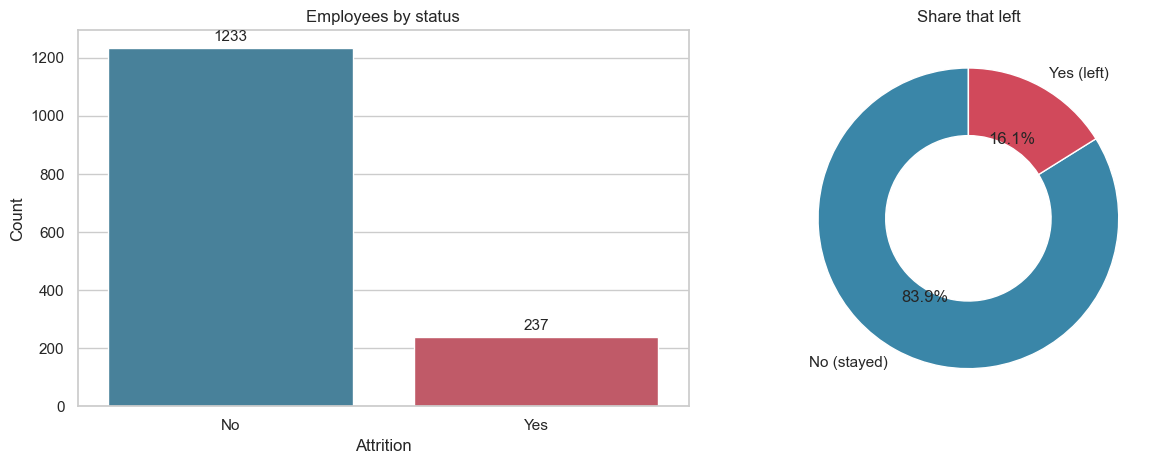

In [14]:
print(df["Attrition"].value_counts())
print()
print((df["Attrition"].value_counts(normalize=True) * 100).round(1))

order = ["No", "Yes"]                                   # fixed order I reuse on charts
counts = df["Attrition"].value_counts().reindex(order)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(x=order, y=counts.values, hue=order, palette=PAL, legend=False, ax=ax[0])
label_bars(ax[0], fmt="%d")                             # label both bars with counts
ax[0].set(title="Employees by status", xlabel="Attrition", ylabel="Count")
ax[1].pie(counts.values, labels=["No (stayed)", "Yes (left)"], autopct="%1.1f%%",
          colors=[PAL["No"], PAL["Yes"]], startangle=90,
          wedgeprops=dict(width=0.45, edgecolor="white"))
ax[1].set_title("Share that left")
plt.tight_layout()
plt.show()

237 out of 1,470 people left, which is **16.1%**. So the classes are imbalanced, roughly 1 in 6.
That's normal for HR data, but it means I'll keep that 16.1% line on most charts as the baseline to
compare each group against.

## 8. Helper functions (and a quick stats note)

I'll be computing the attrition rate per group over and over, so I wrote a small helper for it.
I also wrote one for the **chi-square test + Cramér's V**, which I use to confirm the headline
result and to build the factor ranking at the end.

Statisitc:

- **p-value** - the chance of seeing a gap this big purely by luck if there were really no
  difference. Below 0.05, I treat the difference as real.
- **Chi-square test** - checks whether a category (like OverTime) and Attrition are related or
  independent.
- **Cramér's V** - the chi-square test tells me *if* there's a relationship; Cramér's V tells me
  *how strong* it is, on a 0-to-1 scale.

I run a chi-square teston the headline factor (Q1), I use a proper A/B test where significance is the whole point
(Q9, gender), and I summarise the strength of *all* the factors once at the end with Cramér's V.

In [15]:
def attrition_rate(col):
    '''Attrition rate (%), headcount and number of leavers for each value of `col`.'''
    grouped = df.groupby(col, observed=True)["AttritionFlag"]
    table = pd.DataFrame({
        "headcount": grouped.size(),
        "n_left": grouped.sum(),
        "attrition_rate_%": (grouped.mean() * 100).round(2),   # rate rounded to 2 dp
    })
    return table.sort_values("attrition_rate_%", ascending=False)


def chi2_test(col):
    '''Chi-square test between `col` and Attrition. Returns (chi2, p_value, Cramers_V).'''
    table = pd.crosstab(df[col], df["Attrition"])      # contingency table for the test
    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Cramér's V, bias-corrected (the correction matters when some groups are small).
    n = table.values.sum()                              # total observations
    r, k = table.shape                                  # rows, columns
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    cramers_v = np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))
    return chi2, p, cramers_v

## Q1. Does working overtime affect attrition?


,headcount,n_left,attrition_rate_%
OverTime,,,
Yes,416,127,30.53
No,1054,110,10.44


chi-square p-value = 8.16e-21   (well below 0.05 -> the gap is not chance)
Cramer's V        = 0.243    (the strongest single factor in the data)


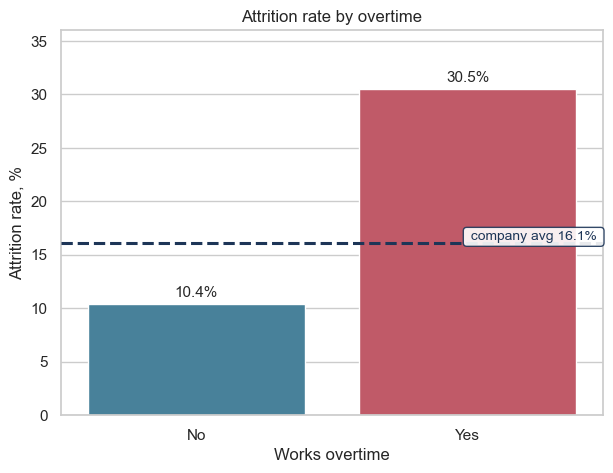

In [16]:
display(attrition_rate("OverTime"))

# Is the gap real, and how strong is it?
chi2, p, v = chi2_test("OverTime")
print(f"chi-square p-value = {p:.2e}   (well below 0.05 -> the gap is not chance)")
print(f"Cramer's V        = {v:.3f}    (the strongest single factor in the data)")

rates = attrition_rate("OverTime").reset_index().sort_values("OverTime")
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=rates, x="OverTime", y="attrition_rate_%",
            hue="OverTime", palette=[PAL["No"], PAL["Yes"]], legend=False, ax=ax)
label_bars(ax, "%.1f%%")
add_avg_line(ax, BASE, orient="h")
ax.set(title="Attrition rate by overtime", xlabel="Works overtime",
       ylabel="Attrition rate, %", ylim=(0, 36))
plt.show()

My guess was right, and the effect is bigger than I thought. People who work overtime leave
**30.5%** of the time versus **10.4%** for everyone else - almost three times as likely. The p-value
is tiny (around 1e-20) so this is clearly not chance, and Cramér's V of 0.24 is the strongest of any
single category in the whole dataset. **Overtime is risk factor number one.**

## Q2. Is salary linked to leaving?

Income is skewed, so on top of the usual t-test I
also run a Mann-Whitney test, which doesn't assume a normal distribution.

,mean,median,std
Attrition,,,
No,6833.0,5204.0,4818.0
Yes,4787.0,3202.0,3640.0


Welch t-test  p = 4.43e-13
Mann-Whitney  p = 2.95e-14


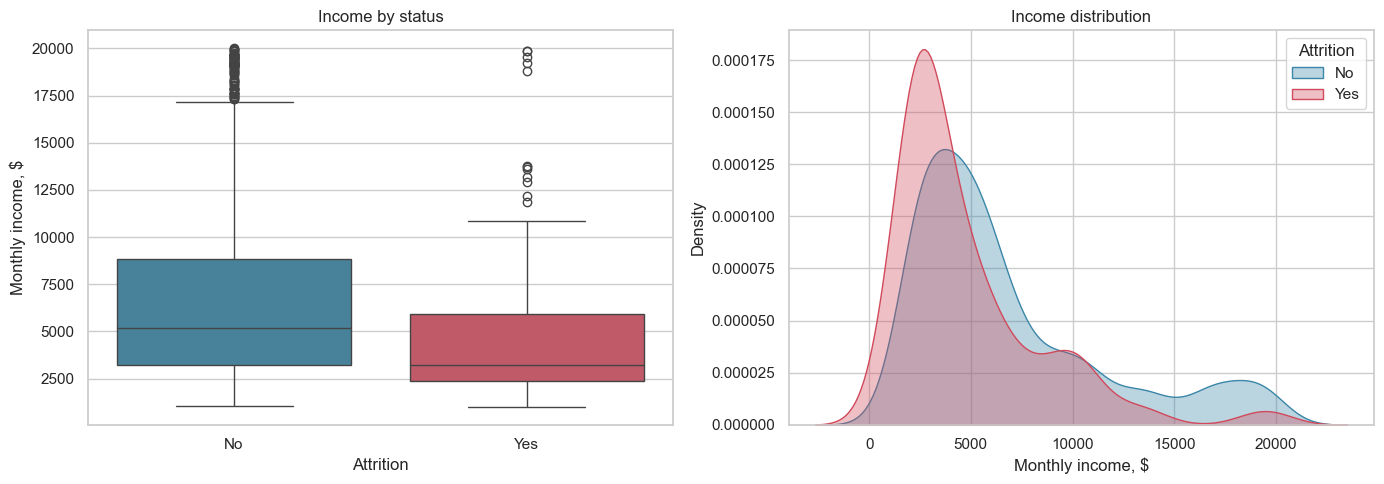

In [17]:
display(df.groupby("Attrition")["MonthlyIncome"].agg(["mean", "median", "std"]).round(0))

left = df.loc[df["AttritionFlag"] == 1, "MonthlyIncome"]    # incomes of people who left
stayed = df.loc[df["AttritionFlag"] == 0, "MonthlyIncome"]  # incomes of people who stayed
t_stat, p_t = stats.ttest_ind(left, stayed, equal_var=False)   # Welch t-test (unequal variance)
u_stat, p_u = stats.mannwhitneyu(left, stayed)                 # rank-based, robust to skew
print(f"Welch t-test  p = {p_t:.2e}")
print(f"Mann-Whitney  p = {p_u:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", hue="Attrition",
            order=order, palette=PAL, legend=False, ax=ax[0])
ax[0].set(title="Income by status", xlabel="Attrition", ylabel="Monthly income, $")
for s in order:
    sns.kdeplot(df.loc[df["Attrition"] == s, "MonthlyIncome"], fill=True, alpha=0.35,
                color=PAL[s], label=s, ax=ax[1])
ax[1].legend(title="Attrition")
ax[1].set(title="Income distribution", xlabel="Monthly income, $", ylabel="Density")
plt.tight_layout()
plt.show()

Confirmed. People who left earned a median of about **\$3,200** versus **\$5,200** for those who
stayed - roughly 38% less. Both tests come back with p well under 0.001. So pay clearly matters, but
the correlation with attrition is only moderate (about -0.16, see the correlation section), which
tells me money is *part* of the story, not the whole story. It probably matters most when it lines
up with other things, which is what Q10 looks at.

## Q3. Which departments and roles lose the most people?


,headcount,n_left,attrition_rate_%
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84


Department,Human Resources,Research & Development,Sales
JobRole,,,
Healthcare Representative,NaN,6.9,NaN
Human Resources,23.1,NaN,NaN
Laboratory Technician,NaN,23.9,NaN
Manager,0.0,5.6,5.4
Manufacturing Director,NaN,6.9,NaN
Research Director,NaN,2.5,NaN
Research Scientist,NaN,16.1,NaN
Sales Executive,NaN,NaN,17.5
Sales Representative,NaN,NaN,39.8


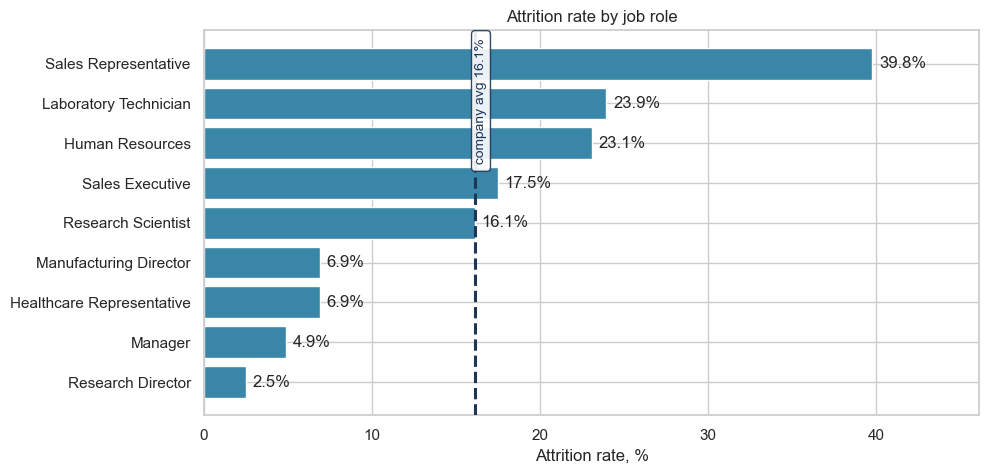

In [18]:
display(attrition_rate("Department"))

# pivot_table averages AttritionFlag for each (JobRole, Department) cell; *100 -> %.
pivot_dept_role = pd.pivot_table(df, values="AttritionFlag", index="JobRole",
                                 columns="Department", aggfunc="mean", observed=True)
pivot_dept_role = (pivot_dept_role * 100).round(1)
display(pivot_dept_role)

role_rates = attrition_rate("JobRole")["attrition_rate_%"].sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(role_rates.index, role_rates.values, color="#3a86a8")
for y, val in enumerate(role_rates.values):     # label every bar
    ax.text(val + 0.4, y, f"{val:.1f}%", va="center")
add_avg_line(ax, BASE, orient="v")
ax.set(title="Attrition rate by job role", xlabel="Attrition rate, %", ylabel="")
ax.margins(x=0.16)
plt.show()

By department, **Sales (20.6%)** and **HR (19.0%)** are above average, R&D (13.8%) is below it. But
the role view is much sharper than the department view: **Sales Representatives leave 39.8% of the
time** - basically two in five - followed by Laboratory Technician (23.9%) and HR (23.1%). At the
other end, Managers (4.9%) and Research Directors (2.5%) almost never leave. So this isn't really a
"department problem", it's a **front-line / entry-level role problem**.

## Q4. Do newer employees leave more often?

,headcount,n_left,attrition_rate_%
TenureBucket,,,
0-1,215,75,34.88
2,127,27,21.26
3-5,434,60,13.82
6-10,448,55,12.28
10+,246,20,8.13


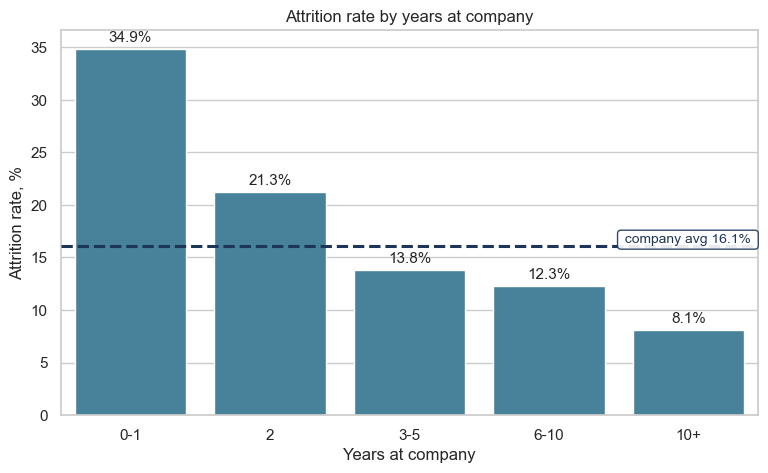

In [19]:
tenure = attrition_rate("TenureBucket").reindex(["0-1", "2", "3-5", "6-10", "10+"])
display(tenure)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=tenure.index, y=tenure["attrition_rate_%"], color="#3a86a8", ax=ax)
label_bars(ax, "%.1f%%")
add_avg_line(ax, BASE, orient="h")
ax.set(title="Attrition rate by years at company", xlabel="Years at company",
       ylabel="Attrition rate, %")
plt.show()

Yes, and it's steep. **34.9%** of people leave in their first year, 21.3% in year two, and only
**8.1%** among those who've been here 10+ years. The average tenure of leavers is 5.1 years versus
7.4 for those who stay. The clear takeaway: the first year is where the company bleeds people, so
that's where onboarding effort pays off most.

## Q5. How do job satisfaction and work-life balance matter?

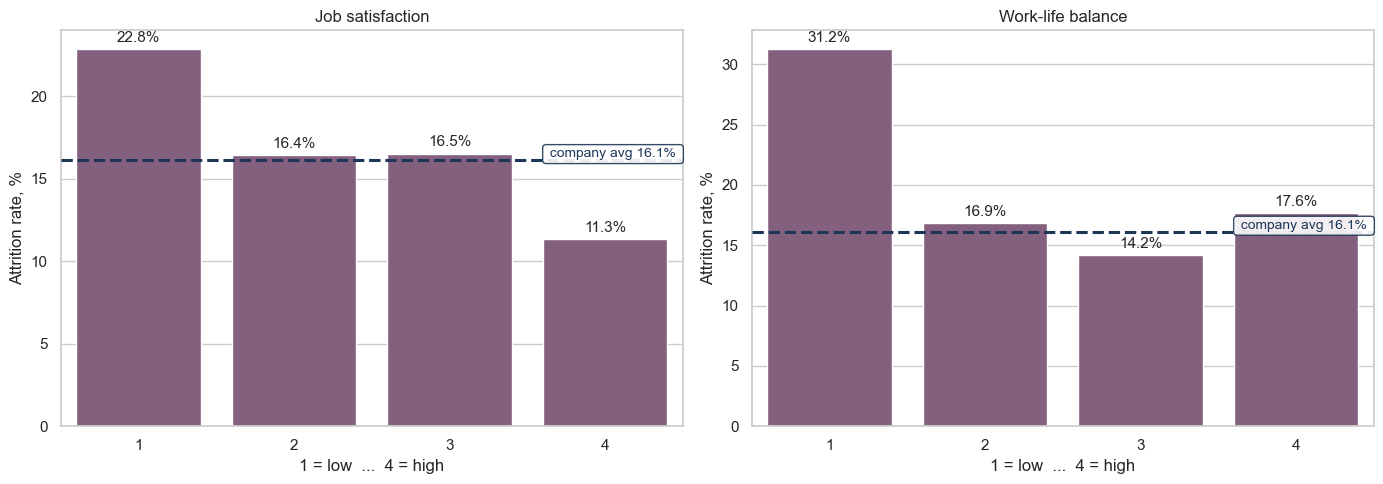

Attrition rate (%) - JobSatisfaction (rows) x WorkLifeBalance (cols):


WorkLifeBalance,1,2,3,4
JobSatisfaction,,,,
1,47.1,21.3,21.4,20.7
2,22.2,13.8,14.9,27.6
3,38.1,17.8,15.8,8.5
4,20.8,15.3,7.2,18.8


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for axis, (col, label) in zip(ax, [("JobSatisfaction", "Job satisfaction"),
                                    ("WorkLifeBalance", "Work-life balance")]):
    rates = attrition_rate(col).sort_index()
    sns.barplot(x=rates.index, y=rates["attrition_rate_%"], color="#8a5a83", ax=axis)
    label_bars(axis, "%.1f%%")
    add_avg_line(axis, BASE, orient="h")
    axis.set(title=label, xlabel="1 = low  ...  4 = high", ylabel="Attrition rate, %")
plt.tight_layout()
plt.show()

# Pivot the two scores against each other to see whether they stack.
pivot_sat = pd.pivot_table(df, values="AttritionFlag", index="JobSatisfaction",
                           columns="WorkLifeBalance", aggfunc="mean", observed=True)
pivot_sat = (pivot_sat * 100).round(1)
print("Attrition rate (%) - JobSatisfaction (rows) x WorkLifeBalance (cols):")
display(pivot_sat)

Both matter, in the expected direction: the lowest job satisfaction (level 1) gives 22.8% attrition
versus 11.3% at level 4, and the worst work-life balance reaches about 31%. The interesting bit is
the pivot table - the two stack. When someone has the **lowest job satisfaction *and* the worst
work-life balance, 47.1%** of them leave. (Both factors are statistically significant; you can see
them in the combined ranking near the end.)

## Q6. Does age matter?

,headcount,n_left,attrition_rate_%
AgeBucket,,,
18-25,123,44,35.77
26-30,263,56,21.29
31-35,343,60,17.49
36-40,276,25,9.06
41-45,192,18,9.38
46+,273,34,12.45


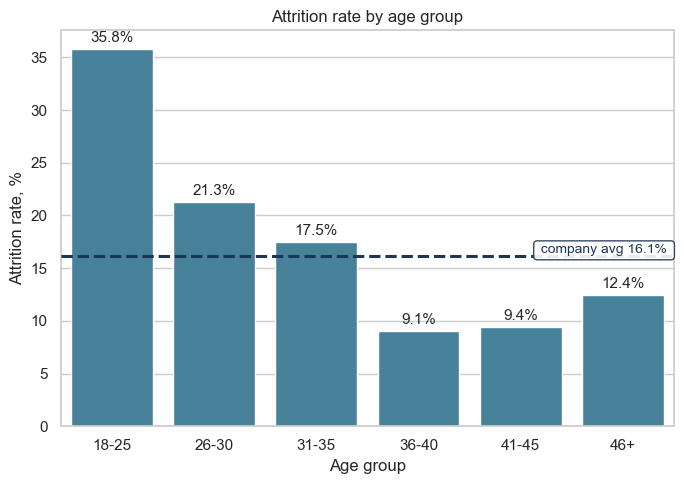

In [21]:
age = attrition_rate("AgeBucket").reindex(["18-25", "26-30", "31-35", "36-40", "41-45", "46+"])
display(age)

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    x=age.index,
    y=age["attrition_rate_%"],
    color="#3a86a8",
    ax=ax
)

label_bars(ax, "%.1f%%")
add_avg_line(ax, BASE, orient="h")

ax.set(
    title="Attrition rate by age group",
    xlabel="Age group",
    ylabel="Attrition rate, %"
)

plt.tight_layout()
plt.show()

The youngest group (18-25) leaves most, at **35.8%**, and the rate drops steadily with age down to
about 9% in the late 30s. Mean age of leavers is 33.6 versus 37.6. I'd read age here mostly as a
**stand-in for tenure and seniority** - young usually means new and junior, which are the same people
showing up in Q3 and Q4.

## Q7. Marital status and business travel

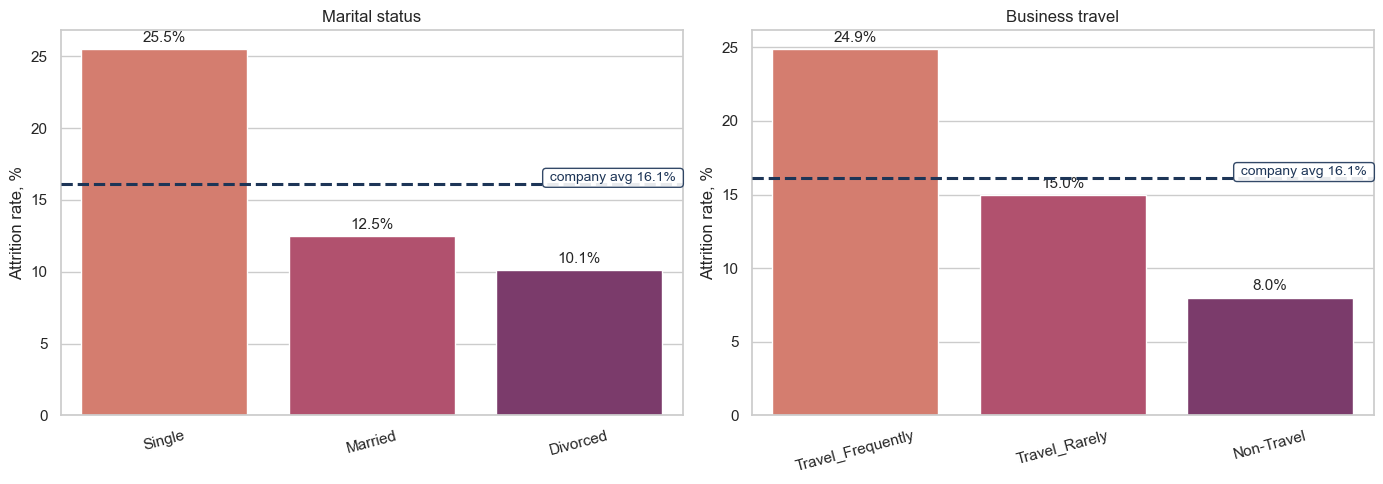

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for axis, col, label in [(ax[0], "MaritalStatus", "Marital status"),
                         (ax[1], "BusinessTravel", "Business travel")]:
    rates = attrition_rate(col)
    sns.barplot(x=rates.index, y=rates["attrition_rate_%"], hue=rates.index,
                palette="flare", legend=False, ax=axis)
    label_bars(axis, "%.1f%%")
    add_avg_line(axis, BASE, orient="h")
    axis.set(title=label, xlabel="", ylabel="Attrition rate, %")
    axis.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**Single** employees leave twice as often as married ones (25.5% vs 12.5%), and people who travel
frequently leave a lot more (24.9%) than people who don't travel at all (8.0%). I suspect a chunk of
the "single" effect is really the age effect again - singles skew younger - but it still points HR
at who needs extra attention. (Both factors are significant in the ranking at the end.)

## Q8. Do stock options and job level protect retention?

In [23]:
display(attrition_rate("StockOptionLevel"))
display(attrition_rate("JobLevel"))

,headcount,n_left,attrition_rate_%
StockOptionLevel,,,
0,631,154,24.41
3,85,15,17.65
1,596,56,9.40
2,158,12,7.59


,headcount,n_left,attrition_rate_%
JobLevel,,,
1,543,143,26.34
3,218,32,14.68
2,534,52,9.74
5,69,5,7.25
4,106,5,4.72


Both protect, clearly. People with **no stock options leave 24.4%** of the time, while people on
levels 1 and 2 drop to roughly 8-9%. (Level 3 is an odd exception at 17.6%, but it's only 85 people,
so I wouldn't read too much into it.) Same shape for job level: entry level (JobLevel 1) sits at
**26.3%**, while levels 4-5 are under 8%. Equity and a real career ladder both look like strong anchors.

## Q9. Is there a real difference between men and women? (A/B test)

This is the one I genuinely didn't know the answer to, so I wanted to test it properly rather than
eyeball it. This is exactly the kind of "are these two rates really different?" question an
**A/B test** answers, so I run a **two-proportion z-test**.

> H0 (null): men and women leave at the same rate.
> H1: the rates are different.

In [24]:
table = pd.crosstab(df["Gender"], df["Attrition"])
display(table)
display(attrition_rate("Gender"))

# Two-proportion z-test, written out by hand so the logic is visible.
n_male, n_female = table.loc["Male"].sum(), table.loc["Female"].sum()   # group sizes
x_male, x_female = table.loc["Male", "Yes"], table.loc["Female", "Yes"] # leavers in each group
p_male, p_female = x_male / n_male, x_female / n_female                 # each group's rate
pooled = (x_male + x_female) / (n_male + n_female)                      # rate if H0 were true
se = np.sqrt(pooled * (1 - pooled) * (1 / n_male + 1 / n_female))       # standard error
z = (p_male - p_female) / se                                           # test statistic
p_value = 2 * (1 - stats.norm.cdf(abs(z)))                             # two-sided p-value

print(f"Male attrition  : {p_male * 100:.2f}%")
print(f"Female attrition: {p_female * 100:.2f}%")
print(f"z = {z:.2f},  p-value = {p_value:.3f}")

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


,headcount,n_left,attrition_rate_%
Gender,,,
Male,882,150,17.01
Female,588,87,14.80


Male attrition  : 17.01%
Female attrition: 14.80%
z = 1.13,  p-value = 0.259


Here the hypothesis is **rejected**, and I'm glad I tested it instead of assuming. Men leave 17.0%
of the time, women 14.8%. The p-value is **0.26**, well above 0.05, so that gap is just sampling
noise - there's no real difference by gender. This actually matters in practice: it stops HR from
"fixing" a problem that doesn't exist, and acting on gender would be both pointless and a
discrimination risk. A clean example of a hypothesis that *should* be rejected.

## Q10. Do the risk factors stack on top of each other?


IncomeQuartile,Q1 (low),Q2,Q3,Q4 (high)
OverTime,,,,
No,17.5,10.0,7.0,7.2
Yes,58.5,26.0,19.3,18.1


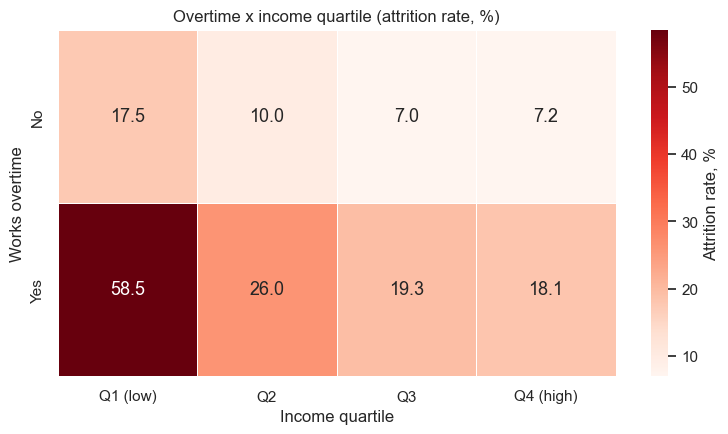

In [25]:
pivot_ot_income = pd.pivot_table(df, values="AttritionFlag", index="OverTime",
                                 columns="IncomeQuartile", aggfunc="mean", observed=True)
pivot_ot_income = (pivot_ot_income * 100).round(1)
display(pivot_ot_income)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot_ot_income, annot=True, fmt=".1f", cmap="Reds", linewidths=0.5,
            cbar_kws={"label": "Attrition rate, %"}, annot_kws={"size": 13}, ax=ax)
ax.set(title="Overtime x income quartile (attrition rate, %)",
       xlabel="Income quartile", ylabel="Works overtime")
plt.show()

They absolutely stack. The worst corner - **overtime plus the lowest income quartile - hits 58.5%**,
nearly six in ten leaving. The safest corner (no overtime, top income) is 7.2%. That's about an
eight-fold difference between the best and worst segments. The practical lesson is that HR should
target **combinations** of risk, not chase one factor at a time.

## Correlation and the final factor ranking

Two last pieces: a correlation heatmap for the numeric columns, and a ranking of every categorical
factor by Cramér's V. The ranking is the one place I look at significance across *all* the factors
at once, instead of testing each one separately above.

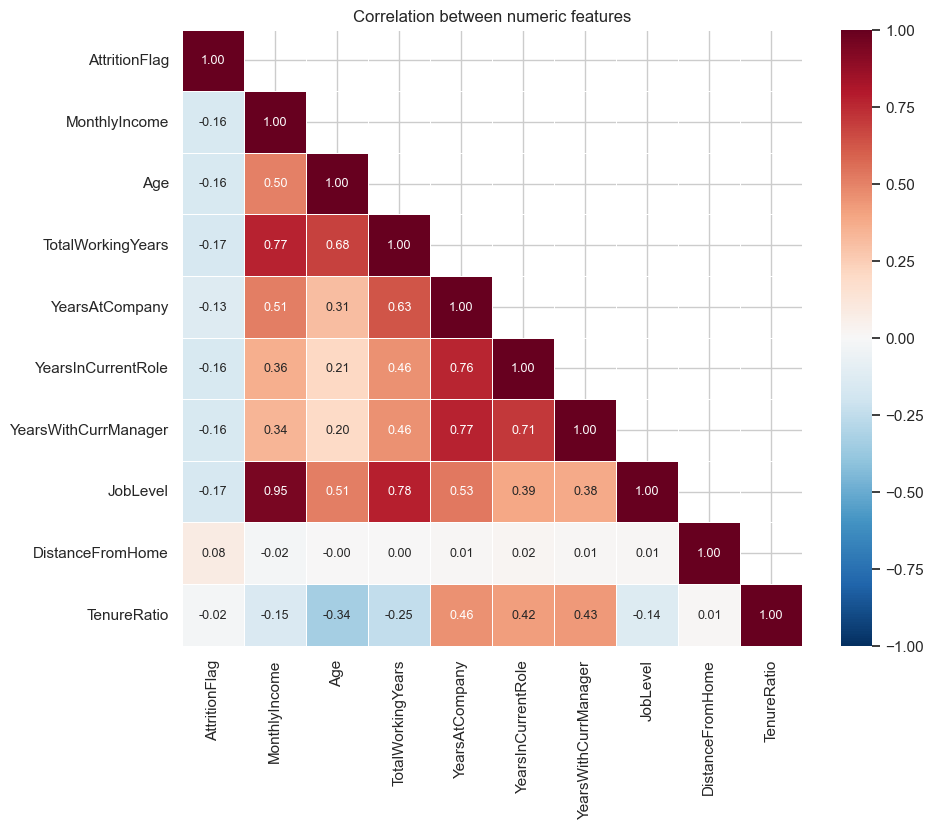

In [26]:
corr_cols = ["AttritionFlag", "MonthlyIncome", "Age", "TotalWorkingYears", "YearsAtCompany",
             "YearsInCurrentRole", "YearsWithCurrManager", "JobLevel", "DistanceFromHome",
             "TenureRatio"]
corr = df[corr_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool), 1)   # hide the mirror-image upper triangle

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation between numeric features")
plt.show()

,factor,chi2,p_value,cramers_v,significant
0,OverTime,87.6,8.158424e-21,0.243,True
1,JobRole,86.2,2.752482e-15,0.231,True
2,JobLevel,72.5,6.634685e-15,0.216,True
3,StockOptionLevel,60.6,4.379390e-13,0.198,True
4,MaritalStatus,46.2,9.455511e-11,0.173,True
5,JobInvolvement,28.5,2.863181e-06,0.132,True
6,BusinessTravel,24.2,5.608614e-06,0.123,True
7,EnvironmentSatisfaction,22.5,5.123469e-05,0.115,True
8,JobSatisfaction,17.5,5.563005e-04,0.099,True
9,WorkLifeBalance,16.3,9.725699e-04,0.095,True


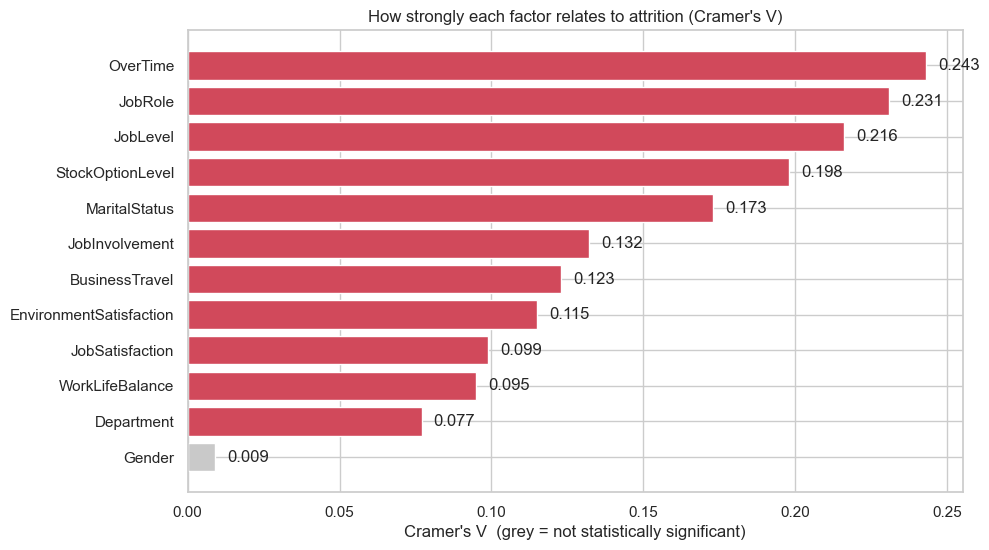

In [27]:
categorical = ["OverTime", "JobRole", "JobLevel", "StockOptionLevel", "MaritalStatus",
               "JobInvolvement", "BusinessTravel", "EnvironmentSatisfaction",
               "JobSatisfaction", "WorkLifeBalance", "Department", "Gender"]

rows = []
for col in categorical:
    chi2, p, v = chi2_test(col)              # compute once per factor and reuse the result
    rows.append({"factor": col, "chi2": round(chi2, 1), "p_value": p,
                 "cramers_v": round(v, 3), "significant": p < 0.05})

ranking = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
display(ranking)

ranking_plot = ranking.sort_values("cramers_v")
colors = [PAL["Yes"] if sig else "#c9c9c9" for sig in ranking_plot["significant"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ranking_plot["factor"], ranking_plot["cramers_v"], color=colors)
for y, val in enumerate(ranking_plot["cramers_v"]):    # label every bar
    ax.text(val + 0.004, y, f"{val:.3f}", va="center")
ax.set(title="How strongly each factor relates to attrition (Cramer's V)",
       xlabel="Cramer's V  (grey = not statistically significant)", ylabel="")
plt.show()

Two takeaways from this. First, the numeric correlations with attrition are all weak (none stronger
than about 0.17), which is exactly why I leaned on categories and combinations - no single number
predicts who leaves. The heatmap also shows the tenure columns are tangled together (0.6-0.8
correlation), so they're really measuring the same "seniority" idea.

Second, the final ranking lines up nicely with everything above:
`OverTime (0.24) > JobRole (0.23) > JobLevel (0.22) > StockOptionLevel (0.20) > MaritalStatus (0.17)`
and so on. **Gender (0.01) is the only factor that isn't significant** - the same conclusion as the
A/B test in Q9.

## Conclusions and recommendations

### What I found

1. **Overtime is the single biggest driver** - 30.5% vs 10.4%, about 3x, and the strongest factor overall.
2. **Pay matters but doesn't explain everything** - leavers earn ~38% less (median), yet income only
   correlates moderately with leaving.
3. **The first year is critical** - 34.9% of newcomers leave in year one, dropping to 8% after a decade.
4. **Risk sits in front-line and junior roles** - Sales Reps 39.8%, entry-level (JobLevel 1) 26.3%.
5. **Satisfaction and work-life balance stack** - the worst combination reaches 47%.
6. **Stock options and seniority hold people** - no options 24.4%, with options ~9%.
7. **Gender has no effect** (p = 0.26) - the hypothesis I rejected.
8. **Factors multiply** - overtime + low pay = 58.5%, roughly 8x the safest group.

### What I'd recommend to HR

| Priority | Action | Why (evidence) |
|----------|--------|----------------|
| High | Cap and properly compensate overtime; rebalance overloaded teams | overtime 30.5% vs 10.4% |
| High | Build a real 0-12 month onboarding program (mentor, 30/60/90-day check-ins, clear career path) | 34.9% leave in year one |
| High | Benchmark and fix pay for Sales Reps, Lab Technicians and entry-level roles | Sales Rep 39.8%, leavers earn -38% |
| Medium | Extend stock options to critical junior/front-line roles | no options 24.4% vs ~9% |
| Medium | Run regular satisfaction / work-life pulse surveys and act on scores of 1-2 | worst combo 47% |
| Targeting | Score risk by a *combination* of factors (overtime + low pay + under 1 year + no options) and reach out proactively | combined risk 58.5% |

The clearest quick win is the **"overtime + low income" group at 58.5%**. Just pulling that segment
back toward the company average would save a meaningful amount of rehiring and retraining cost.

### Limitations

The data is synthetic and it's a single snapshot, so everything here is correlation, not proof of
cause - I can't see what changed right before someone quit. `PerformanceRating` was unusable (only
3s and 4s).